Dicke weight           amplitude
logical state component                                  
|0_L>         0                     0  0.500000+0.000000j
              1                     6  0.866025+0.000000j
|1_L>         0                     3  0.866025+0.000000j
              1                     9  0.500000+0.000000j

p = 5.00e-05
p = 7.46e-05
p = 1.11e-04
p = 1.66e-04
p = 2.48e-04
p = 3.70e-04
p = 5.51e-04
p = 8.23e-04
p = 1.23e-03
p = 1.83e-03
p = 2.73e-03
p = 4.07e-03
p = 6.08e-03
p = 9.07e-03
p = 1.35e-02
p = 2.02e-02
p = 3.01e-02
p = 4.49e-02
p = 6.70e-02
p = 1.00e-01


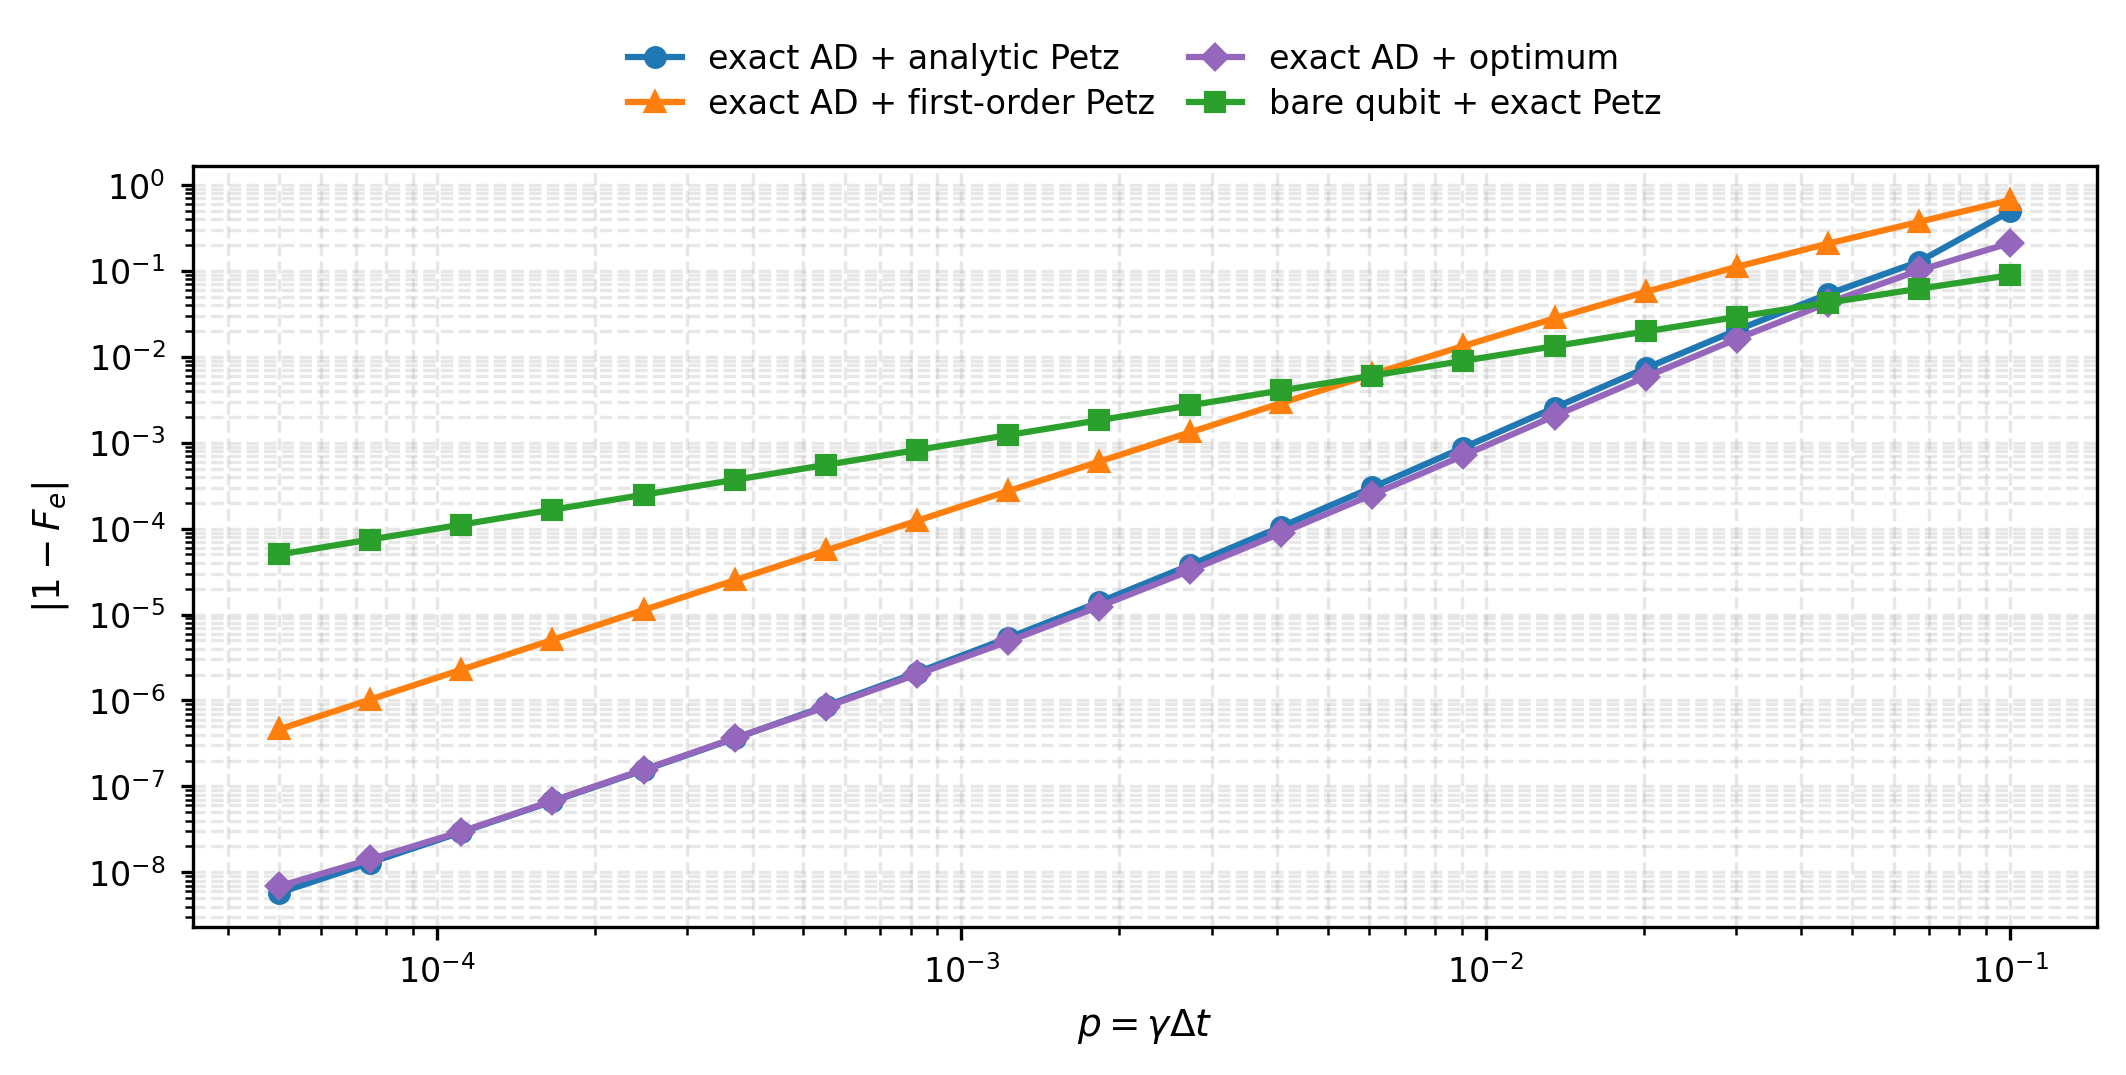

,p,exact_bgm_analytic_petz,exact_bgm_first_order_petz,exact_bgm_optimum,approx_bgm_analytic_petz,exact_bgm_no_recovery,approx_bgm_no_recovery,bare_qubit_exact_petz,approx_minus_exact,approx_over_exact
0,0.000050,5.774339e-09,4.609374e-07,6.871608e-09,5.509536e-09,0.000432,0.000900,0.000050,-2.648030e-10,0.954141
1,0.000075,1.296393e-08,1.025539e-06,1.415845e-08,1.213642e-08,0.000644,0.001342,0.000075,-8.275096e-10,0.936168
2,0.000111,2.931677e-08,2.281382e-06,2.980776e-08,2.659272e-08,0.000960,0.002001,0.000111,-2.724051e-09,0.907082
3,0.000166,6.698590e-08,5.073963e-06,6.792463e-08,5.779391e-08,0.001431,0.002984,0.000166,-9.191993e-09,0.862777
4,0.000248,1.542312e-07,1.128008e-05,1.567921e-07,1.240010e-07,0.002133,0.004448,0.000248,-3.023020e-08,0.803994
5,0.000370,3.612031e-07,2.506347e-05,3.646572e-07,2.605982e-07,0.003176,0.006627,0.000369,-1.006049e-07,0.721473
6,0.000551,8.618371e-07,5.564070e-05,8.386045e-07,5.288486e-07,0.004727,0.009869,0.000551,-3.329885e-07,0.613629
7,0.000823,2.111309e-06,1.233671e-04,2.011217e-06,1.006896e-06,0.007026,0.014685,0.000822,-1.104413e-06,0.476906
8,0.001227,5.330937e-06,2.730126e-04,4.858625e-06,1.674732e-06,0.010424,0.021820,0.001225,-3.656206e-06,0.314153
9,0.001831,1.393034e-05,6.024841e-04,1.236767e-05,1.840764e-06,0.015423,0.032358,0.001827,-1.208958e-05,0.132141


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import qutip as qt
import matplotlib.pyplot as plt
from IPython.display import display

# Compact comparison: exact/approx global AD with the four Eq. 17 analytic Petz recovery Kraus operators.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "codes").exists())
sys.path.insert(0, str(repo_root / "src"))

from qer.codewords import bgmcode_kets_in_top_block, bgmcode_piqs
from qer.noisemodel import noisemodel
from qer.optimisation import no_recovery, optimise
from qer.bk_recovery import (
    approx_global_ad_petz_recovery_kraus,
    first_order_global_ad_petz_recovery_kraus,
    fidelity_bk_recovery,
    fidelity_with_recovery_kraus,
)

b, g, m = 3, 3, 1
N = 2 * b * m + g
dt = 1.0
gamma_vals = np.logspace(np.log10(5e-5), -1, 20)
p_vals = gamma_vals * dt
sdp_solver = "mosek"
noise_name = "global symmetric amplitude damping"

rho_bgm, l0_bgm, l1_bgm = bgmcode_piqs(b, g, m, return_qutip=True)
l0_bare, l1_bare = qt.basis(2, 0), qt.basis(2, 1)
ket0_top, ket1_top, _ = bgmcode_kets_in_top_block(b, g, m)

def nonzero_dicke_components(ket, tol=1e-12):
    return pd.DataFrame([
        {"Dicke weight": w, "amplitude": amp}
        for w, amp in enumerate(np.asarray(ket).ravel())
        if abs(amp) > tol
    ])

display(pd.concat({
    "|0_L>": nonzero_dicke_components(ket0_top),
    "|1_L>": nonzero_dicke_components(ket1_top),
}, names=["logical state", "component"]))

infid_exact_analytic_petz_bgm, infid_exact_first_order_petz_bgm = [], []
infid_optimum_bgm, infid_approx_analytic_petz_bgm = [], []
infid_exact_no_recovery_bgm, infid_approx_no_recovery_bgm, infid_bare = [], [], []

for gamma in gamma_vals:
    print(f"p = {gamma * dt:.2e}")

    exact_bgm = noisemodel(noise_name, N, gamma, dt, return_rep="choi", dynamics="exact")
    E_approx = noisemodel(noise_name, N, gamma, dt, return_rep="kraus", dynamics="approx")
    R_analytic_petz = approx_global_ad_petz_recovery_kraus(N, gamma, dt, ket0=l0_bgm, ket1=l1_bgm)
    R_first_order_petz = first_order_global_ad_petz_recovery_kraus(N, gamma, dt, ket0=l0_bgm, ket1=l1_bgm)
    assert len(R_analytic_petz) == 4
    assert len(R_first_order_petz) == 2

    Fe_exact = fidelity_with_recovery_kraus(l0_bgm, l1_bgm, R_analytic_petz, exact_bgm, method="choi")
    Fe_first_order = fidelity_with_recovery_kraus(l0_bgm, l1_bgm, R_first_order_petz, exact_bgm, method="choi")
    Fe_optimum = optimise(l0_bgm, l1_bgm, exact_bgm, solver=sdp_solver)
    Fe_exact_no_recovery = no_recovery(rho_bgm, exact_bgm)

    Fe_approx = fidelity_with_recovery_kraus(l0_bgm, l1_bgm, R_analytic_petz, E_approx, method="kraus")
    Fe_approx_no_recovery = no_recovery(rho_bgm, E_approx)

    exact_bare = noisemodel(noise_name, 1, gamma, dt, return_rep="choi", dynamics="exact")
    Fe_bare = fidelity_bk_recovery(l0_bare, l1_bare, exact_bare, method="choi")

    infid_exact_analytic_petz_bgm.append(abs(1.0 - float(Fe_exact)))
    infid_exact_first_order_petz_bgm.append(abs(1.0 - float(Fe_first_order)))
    infid_optimum_bgm.append(abs(1.0 - float(Fe_optimum)))
    infid_approx_analytic_petz_bgm.append(abs(1.0 - float(Fe_approx)))
    infid_exact_no_recovery_bgm.append(abs(1.0 - float(Fe_exact_no_recovery)))
    infid_approx_no_recovery_bgm.append(abs(1.0 - float(Fe_approx_no_recovery)))
    infid_bare.append(abs(1.0 - float(Fe_bare)))

df_penalty = pd.DataFrame({
    "p": p_vals,
    "exact_bgm_analytic_petz": np.array(infid_exact_analytic_petz_bgm, dtype=float),
    "exact_bgm_first_order_petz": np.array(infid_exact_first_order_petz_bgm, dtype=float),
    "exact_bgm_optimum": np.array(infid_optimum_bgm, dtype=float),
    "approx_bgm_analytic_petz": np.array(infid_approx_analytic_petz_bgm, dtype=float),
    "exact_bgm_no_recovery": np.array(infid_exact_no_recovery_bgm, dtype=float),
    "approx_bgm_no_recovery": np.array(infid_approx_no_recovery_bgm, dtype=float),
    "bare_qubit_exact_petz": np.array(infid_bare, dtype=float),
})
df_penalty["approx_minus_exact"] = df_penalty["approx_bgm_analytic_petz"] - df_penalty["exact_bgm_analytic_petz"]
df_penalty["approx_over_exact"] = df_penalty["approx_bgm_analytic_petz"] / df_penalty["exact_bgm_analytic_petz"]

fig, ax = plt.subplots(figsize=(7.0, 3.5), dpi=300)
ax.loglog(df_penalty["p"], df_penalty["exact_bgm_analytic_petz"], "o-", color="#1f77b4", lw=1.5, ms=4.5, label="exact AD + analytic Petz")
ax.loglog(df_penalty["p"], df_penalty["exact_bgm_first_order_petz"], "^-", color="#ff7f0e", lw=1.5, ms=4.3, label="exact AD + first-order Petz")
ax.loglog(df_penalty["p"], df_penalty["exact_bgm_optimum"], "D-", color="#9467bd", lw=1.5, ms=4.0, label="exact AD + optimum")
# ax.loglog(df_penalty["p"], df_penalty["approx_bgm_analytic_petz"], "^-", color="#d62728", lw=1.5, ms=4.5, label="approx AD + analytic Petz")
# ax.loglog(df_penalty["p"], df_penalty["exact_bgm_no_recovery"], "x-", color="#7f7f7f", lw=1.8, ms=7, label="exact global AD + no recovery")
# ax.loglog(df_penalty["p"], df_penalty["approx_bgm_no_recovery"], "x--", color="#ff7f0e", lw=1.8, ms=7, label="approx global AD + no recovery")
ax.loglog(df_penalty["p"], df_penalty["bare_qubit_exact_petz"], "s-", color="#2ca02c", lw=1.5, ms=4.2, label="bare qubit + exact Petz")
ax.set_xlabel(r"error probability ($p = \gamma\Delta t$)", fontsize=9)
ax.set_ylabel(r"Entanglement infidelity $(1-F_e)$", fontsize=9)
ax.grid(True, which="both", ls="--", alpha=0.30)
ax.tick_params(axis="both", which="major", labelsize=8, length=3)
ax.tick_params(axis="both", which="minor", length=2)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=8,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.0,
    labelspacing=0.35,
)
fig.tight_layout(pad=0.4)
plt.show()

display(df_penalty)

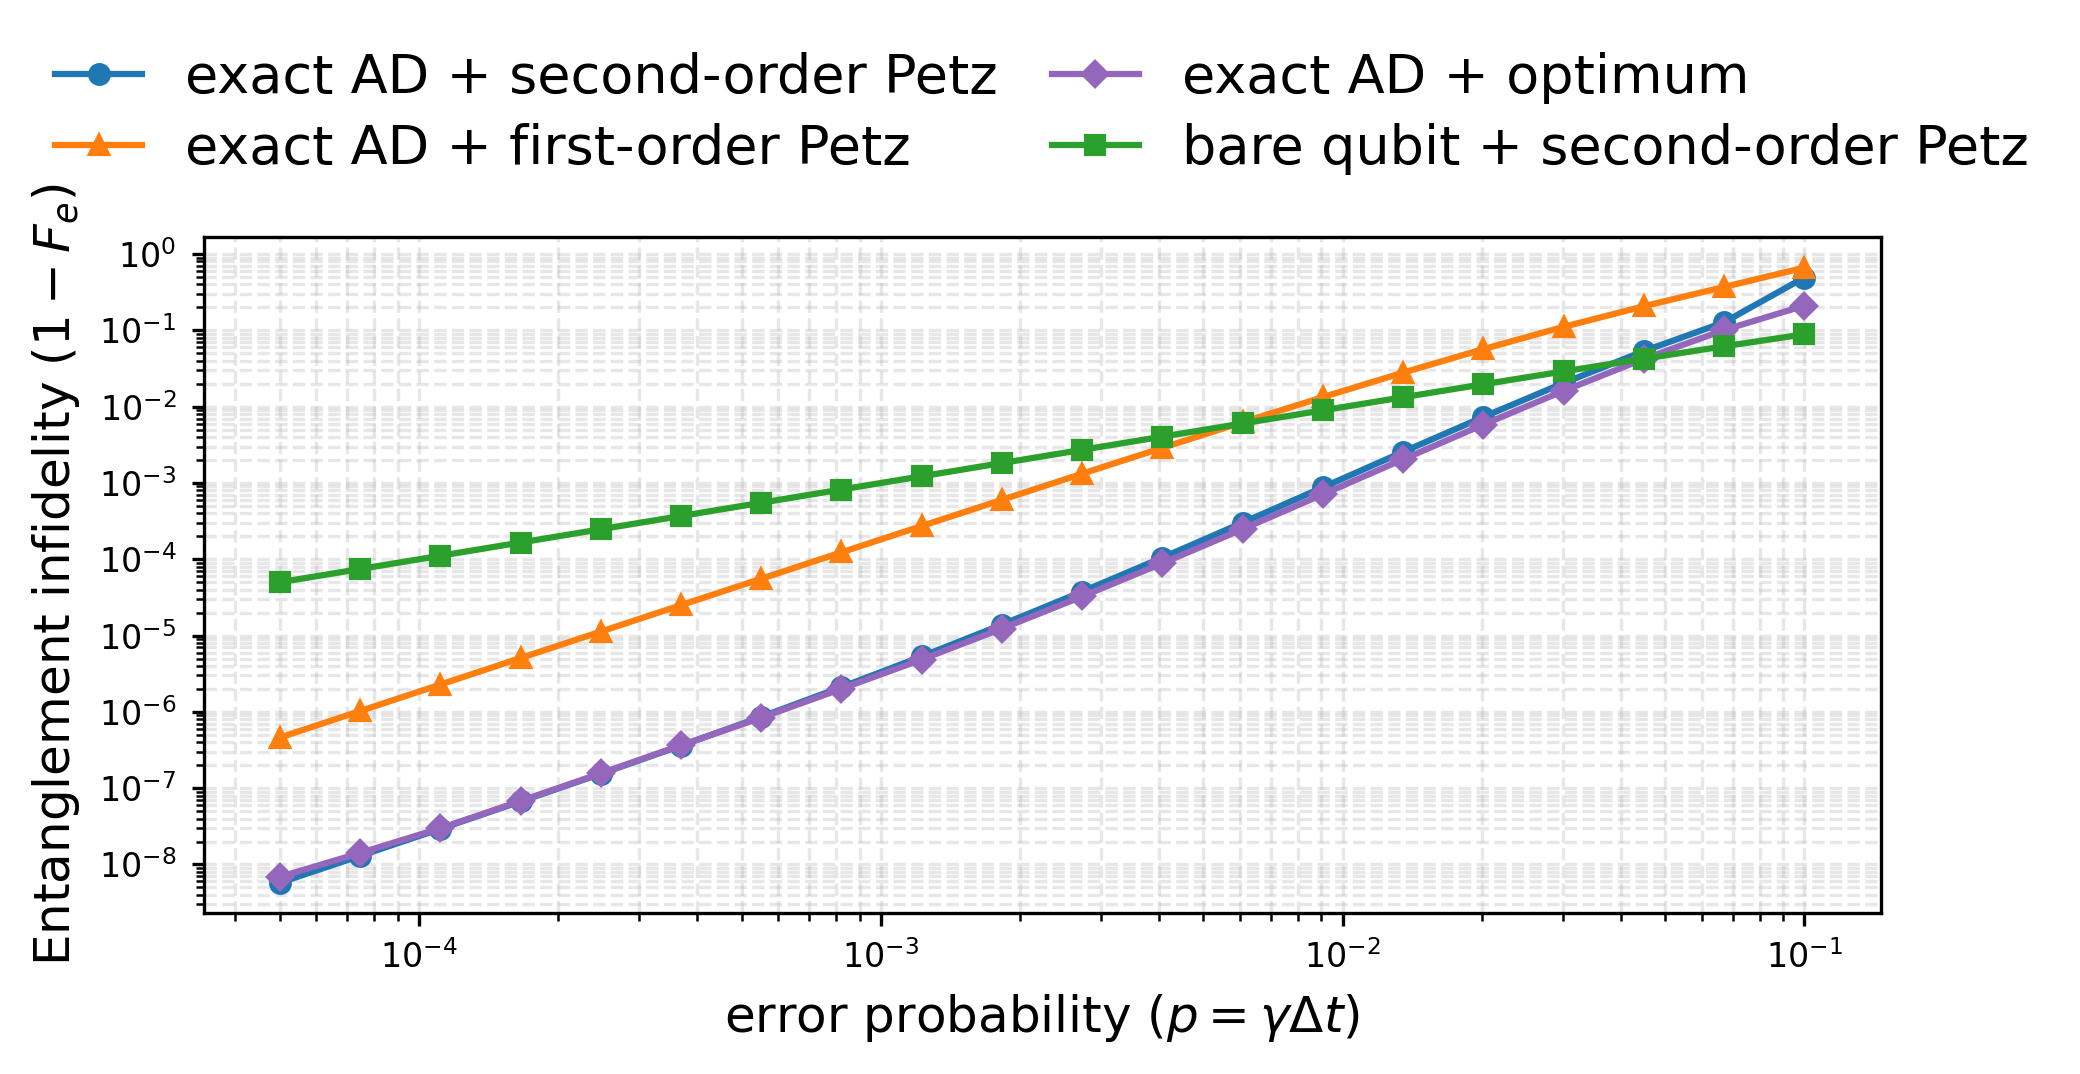

In [10]:
fig, ax = plt.subplots(figsize=(7.0, 3.5), dpi=300)

ax.loglog(
    df_penalty["p"],
    df_penalty["exact_bgm_analytic_petz"],
    "o-",
    color="#1f77b4",
    lw=1.5,
    ms=4.5,
    label="exact AD + second-order Petz",
)

ax.loglog(
    df_penalty["p"],
    df_penalty["exact_bgm_first_order_petz"],
    "^-",
    color="#ff7f0e",
    lw=1.5,
    ms=4.3,
    label="exact AD + first-order Petz",
)

ax.loglog(
    df_penalty["p"],
    df_penalty["exact_bgm_optimum"],
    "D-",
    color="#9467bd",
    lw=1.5,
    ms=4.0,
    label="exact AD + optimum",
)

ax.loglog(
    df_penalty["p"],
    df_penalty["bare_qubit_exact_petz"],
    "s-",
    color="#2ca02c",
    lw=1.5,
    ms=4.2,
    label="bare qubit + second-order Petz",
)

ax.set_xlabel(r"error probability ($p = \gamma\Delta t$)", fontsize=12)
ax.set_ylabel(r"Entanglement infidelity $(1-F_e)$", fontsize=12)

ax.grid(True, which="both", ls="--", alpha=0.30)
ax.tick_params(axis="both", which="major", labelsize=8, length=3)
ax.tick_params(axis="both", which="minor", length=2)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=13,
    frameon=False,
    handlelength=1.6,
    columnspacing=1.0,
    labelspacing=0.35,
)

fig.tight_layout(pad=0.4)
plt.show()